# EV Charging Stations — Jakarta / Indonesia

Multi-source exploratory analysis of public EV charging infrastructure.

**Data sources**

| # | Source | Type | Notes |
|---|--------|------|-------|
| 1 | [Satu Data Jakarta — SPKLU](https://satudata.jakarta.go.id/open-data/detail?kategori=dataset&page_url=data-stasiun-pengisian-kendaraan-listrik-umum-spklu) | CSV/XLSX (manual download) | Official Jakarta public-charging registry |
| 2 | [Open Charge Map](https://openchargemap.org/) | REST API | Crowd-sourced global POIs — needs API key |
| 3 | [OSM `amenity=charging_station`](https://wiki.openstreetmap.org/wiki/Tag:amenity%3Dcharging_station) | Overpass API | Live OSM query |
| 4 | [BPS Jakarta — vehicle stats](https://jakarta.bps.go.id/en/statistics-table/3/V1ZSbFRUY3lTbFpEYTNsVWNGcDZjek53YkhsNFFUMDkjMw) | HTML/CSV (manual download) | Denominator for EV-per-station |
| 5 | [Kaggle — Indonesia EV Dataset 2026](https://www.kaggle.com/datasets/arsan5623/indonesia-electric-vehicle-ev-dataset-2026) | CSV (Kaggle API or manual) | EV registrations / models |
| 6 | [Geofabrik Java PBF](https://download.geofabrik.de/asia/indonesia/java.html) | PBF dump | Bulk OSM — use only if Overpass times out |
| 7 | [OSRM](https://project-osrm.org/docs/v5.24.0/api/) | REST API | Drive-time isochrones / accessibility |

**Pipeline.** Each source has its own load cell that writes a tidy dataframe; later sections cross-join them (e.g. station density vs. EV fleet vs. drive-time coverage).

## 0. Setup

In [1]:
# %pip install -q -r requirements.txt

In [2]:
import os
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv()

RAW_DIR        = Path(os.getenv('RAW_DIR', './data/raw'))
PROCESSED_DIR  = Path(os.getenv('PROCESSED_DIR', './data/processed'))
OUTPUT_DIR     = Path(os.getenv('OUTPUT_DIR', './output'))
FIGURES_DIR    = Path(os.getenv('FIGURES_DIR', './output/figures'))
for d in (RAW_DIR, PROCESSED_DIR, OUTPUT_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

BBOX = {
    'south': float(os.getenv('JAKARTA_BBOX_SOUTH', -6.3760)),
    'west':  float(os.getenv('JAKARTA_BBOX_WEST',  106.6894)),
    'north': float(os.getenv('JAKARTA_BBOX_NORTH', -6.0890)),
    'east':  float(os.getenv('JAKARTA_BBOX_EAST',  106.9710)),
}
CENTER = (float(os.getenv('JAKARTA_CENTER_LAT', -6.2088)),
          float(os.getenv('JAKARTA_CENTER_LON', 106.8456)))
TIMEOUT = int(os.getenv('REQUEST_TIMEOUT_SECONDS', 30))
UA      = os.getenv('USER_AGENT', 'ev-charging-analysis-jakarta/0.1')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

print('Working dir :', Path.cwd())
print('Jakarta bbox:', BBOX)

Working dir : C:\Users\arief\Documents\industrial_experience\dataset
Jakarta bbox: {'south': -6.65, 'west': 106.55, 'north': -5.95, 'east': 107.1}


In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorised great-circle distance (km)."""
    R = 6371.0088
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

def in_jakarta_bbox(lat, lon):
    return (BBOX['south'] <= lat <= BBOX['north']) and (BBOX['west'] <= lon <= BBOX['east'])

## 1. PLN SPKLU — national charging registry

The official PLN SPKLU dataset (3,029 stations nationwide) is cached at `data/raw/_petaspklu_all.json`.
Fields: `provinsi`, `kabupaten_kota`, `nama_lokasi`, `alamat`, `latitude`, `longitude`, `watt`, `type_charge`, `total_konektor`.


In [4]:
import math

pln_path = RAW_DIR / '_petaspklu_all.json'
if pln_path.exists():
    pln_raw = json.load(open(pln_path, encoding='utf-8'))
    rows = []
    for r in pln_raw:
        try:
            lat, lon = float(r.get('latitude')), float(r.get('longitude'))
        except (TypeError, ValueError):
            continue
        if not (math.isfinite(lat) and math.isfinite(lon)) or (lat == 0 and lon == 0):
            continue
        rows.append({
            'name': r.get('nama_lokasi'), 'lat': lat, 'lon': lon,
            'address': r.get('alamat'), 'province': (r.get('provinsi') or '').strip(),
            'city': r.get('kabupaten_kota'),
            'power_kw': pd.to_numeric(str(r.get('watt','')).split()[0], errors='coerce') if r.get('watt') else np.nan,
            'type_charge': r.get('type_charge'),
            'connectors': r.get('total_konektor'), 'operator': 'PLN', 'source': 'pln_spklu',
        })
    spklu = pd.DataFrame(rows)
    print(f'PLN: {len(pln_raw):,} raw -> {len(spklu):,} with valid coords')
    print('Top provinces:', spklu['province'].value_counts().head(5).to_dict())
    display(spklu.head())
else:
    print(f'!! {pln_path} not found')
    spklu = pd.DataFrame(columns=['name','lat','lon','power_kw','connectors','operator','source'])


PLN: 3,029 raw -> 3,029 with valid coords
Top provinces: {'DKI Jakarta': 731, 'Jawa Barat': 539, 'Banten': 295, 'Jawa Timur': 245, 'Jawa Tengah': 220}


,name,lat,lon,address,province,city,power_kw,type_charge,connectors,operator,source
0,SPKLU PLN UID JAKARTA RAYA,-6.180390,106.833191,"Jl. M.I. Ridwan Rais No.1, Gambir",DKI Jakarta,Kota ADM Jakarta Pusat,22,medium,0,PLN,pln_spklu
1,SPKLU AEON Mall BSD,-6.304080,106.643679,"Jl. BSD Raya Utama, Pagedangan",Banten,Kab Tangerang,22,medium,0,PLN,pln_spklu
2,SPKLU Supermall Karawaci,-6.225712,106.607328,"Jl. Boulevard Diponegoro, Bencongan",Banten,Kab Tangerang,25,medium,0,PLN,pln_spklu
3,SPKLU Tangcity,-6.193182,106.633549,"Jl. Jenderal Sudirman No.1, Cikokol",Banten,Kota Tangerang,25,medium,0,PLN,pln_spklu
4,SPKLU PLN UIW S2JB Rivai,-2.979122,104.748281,Jalan Kapt. Arivai no. 37 Palembang,Sumatera Selatan,Kota Palembang,180,ultrafast,0,PLN,pln_spklu


## 2. Open Charge Map API

Free tier needs an API key — see `OCM_API_KEY` in `.env`. We pull all Indonesia POIs and filter to the Jakarta bbox afterwards (one request, no pagination needed at ~few-thousand POI scale).

In [6]:
ocm_key = os.getenv('OCM_API_KEY', '').strip()
ocm_url = os.getenv('OCM_API_URL', 'https://api.openchargemap.io/v3/poi')
ocm_cache = RAW_DIR / 'ocm_jakarta.json'

# Per OCM OpenAPI spec: boundingbox = '(lat1,lng1),(lat2,lng2)' — top-left, bottom-right.
# Querying by bbox is faster and friendlier than pulling all of ID and post-filtering.
ocm_bbox = f"({BBOX['north']},{BBOX['west']}),({BBOX['south']},{BBOX['east']})"

if ocm_cache.exists():
    print(f'Using cached {ocm_cache}')
    with open(ocm_cache, 'r', encoding='utf-8') as f:
        ocm_payload = json.load(f)
elif ocm_key:
    params = {
        'output':       'json',
        'boundingbox':  ocm_bbox,
        'maxresults':   int(os.getenv('OCM_MAX_RESULTS', 5000)),
        'compact':      'true',
        'verbose':      'true',   # need verbose for ConnectionType / UsageType / StatusType titles
        'client':       'ev-charging-analysis-jakarta',
    }
    headers = {'User-Agent': UA, 'X-API-Key': ocm_key}  # spec's recommended auth header
    r = requests.get(ocm_url, params=params, headers=headers, timeout=TIMEOUT)
    r.raise_for_status()
    ocm_payload = r.json()
    with open(ocm_cache, 'w', encoding='utf-8') as f:
        json.dump(ocm_payload, f)
    print(f'Fetched {len(ocm_payload):,} POIs in Jakarta bbox and cached to {ocm_cache}')
else:
    print('!! OCM_API_KEY missing — register at openchargemap.org/site/profile/applications')
    ocm_payload = []


Using cached data\raw\ocm_jakarta.json


In [7]:
def flatten_ocm(poi):
    addr  = poi.get('AddressInfo') or {}
    conns = poi.get('Connections') or []
    op    = poi.get('OperatorInfo') or {}
    usage = poi.get('UsageType')    or {}
    stat  = poi.get('StatusType')   or {}
    # Quantity per Connections entry = bays of that equipment type; sum for total connectors.
    qty   = [c.get('Quantity') or 0 for c in conns]
    power = [c.get('PowerKW') for c in conns if c.get('PowerKW')]
    types = [(c.get('ConnectionType') or {}).get('Title') for c in conns]
    return {
        'ocm_id':           poi.get('ID'),
        'name':             addr.get('Title'),
        'address':          addr.get('AddressLine1'),
        'city':             addr.get('Town'),
        'state':            addr.get('StateOrProvince'),
        'lat':              addr.get('Latitude'),
        'lon':              addr.get('Longitude'),
        'connectors':       sum(qty) if any(qty) else len(conns),
        'num_points':       poi.get('NumberOfPoints'),
        'power_kw':         max(power) if power else np.nan,
        'connection_types': '|'.join(sorted({t for t in types if t})),
        'operator':         op.get('Title'),
        'usage':            usage.get('Title'),
        'is_operational':   stat.get('IsOperational'),
        'date_verified':    poi.get('DateLastVerified'),
        'data_quality':     poi.get('DataQualityLevel'),
        'source':           'open_charge_map',
    }

ocm_all = pd.DataFrame([flatten_ocm(p) for p in ocm_payload]) if ocm_payload else pd.DataFrame()
if not ocm_all.empty:
    # bbox query already filtered server-side; drop any stragglers without coords.
    ocm_jakarta = ocm_all.dropna(subset=['lat','lon']).reset_index(drop=True)
    print(f'OCM POIs returned: {len(ocm_all):,}  |  with coords: {len(ocm_jakarta):,}')
    if 'is_operational' in ocm_jakarta:
        print('Operational breakdown:', ocm_jakarta['is_operational'].value_counts(dropna=False).to_dict())
    display(ocm_jakarta.head())
else:
    ocm_jakarta = pd.DataFrame()


OCM POIs returned: 527  |  with coords: 527
Operational breakdown: {None: 527}


,ocm_id,name,address,city,state,lat,lon,connectors,num_points,power_kw,connection_types,operator,usage,is_operational,date_verified,data_quality,source
0,479002,PLN ULP Babelan,,Bekasi,Jawa Barat,-6.184700,107.038800,5,1,25,,None,None,None,2026-04-04T18:04:00Z,1,open_charge_map
1,480817,Marketing Summarecon Crown Gading,Marketing Summarecon Crown Gading,Bekasi,Jawa Barat,-6.158745,106.999004,2,1,180,,None,None,None,2026-04-04T18:01:00Z,1,open_charge_map
2,479003,KBN Cakung,,Jakarta Utara,DKI Jakarta,-6.144100,106.936100,3,1,50,,None,None,None,2026-04-04T18:10:00Z,1,open_charge_map
3,480821,Grand Waterfront Agung Sedayu,,Jakarta Timur,DKI Jakarta,-6.166220,106.923050,2,1,120,,None,None,None,2026-04-04T18:26:00Z,1,open_charge_map
4,480819,Gading Festival,,Jakarta Timur,DKI Jakarta,-6.169028,106.925170,3,1,50,,None,None,None,2026-04-04T18:09:00Z,1,open_charge_map


## 3. OpenStreetMap — `amenity=charging_station` via Overpass

In [8]:
overpass_url = os.getenv('OVERPASS_API_URL', 'https://overpass-api.de/api/interpreter')
osm_cache    = RAW_DIR / 'osm_charging_jakarta.json'

query = f"""
[out:json][timeout:60];
(
  node["amenity"="charging_station"]({BBOX['south']},{BBOX['west']},{BBOX['north']},{BBOX['east']});
  way["amenity"="charging_station"]({BBOX['south']},{BBOX['west']},{BBOX['north']},{BBOX['east']});
  relation["amenity"="charging_station"]({BBOX['south']},{BBOX['west']},{BBOX['north']},{BBOX['east']});
);
out center tags;
"""

if osm_cache.exists():
    with open(osm_cache, 'r', encoding='utf-8') as f:
        osm_payload = json.load(f)
    print(f'Using cached {osm_cache}')
else:
    r = requests.post(overpass_url, data={'data': query},
                      headers={'User-Agent': UA}, timeout=120)
    r.raise_for_status()
    osm_payload = r.json()
    with open(osm_cache, 'w', encoding='utf-8') as f:
        json.dump(osm_payload, f)
    print(f'Fetched {len(osm_payload.get("elements", [])):,} OSM elements')

Using cached data\raw\osm_charging_jakarta.json


In [9]:
def flatten_osm(el):
    tags = el.get('tags', {}) or {}
    if el['type'] == 'node':
        lat, lon = el.get('lat'), el.get('lon')
    else:
        c = el.get('center') or {}
        lat, lon = c.get('lat'), c.get('lon')
    def _num(v):
        try: return float(str(v).split()[0])
        except Exception: return np.nan
    return {
        'osm_id':     f"{el['type']}/{el['id']}",
        'name':       tags.get('name') or tags.get('operator'),
        'lat':        lat,
        'lon':        lon,
        'connectors': _num(tags.get('capacity')),
        'power_kw':   _num(tags.get('socket:type2_combo:output') or tags.get('charging_station:output')),
        'operator':   tags.get('operator'),
        'access':     tags.get('access'),
        'source':     'osm',
    }

osm = pd.DataFrame([flatten_osm(e) for e in osm_payload.get('elements', [])])
osm = osm.dropna(subset=['lat','lon']).reset_index(drop=True)
print(f'OSM charging stations in Jakarta bbox: {len(osm):,}')
display(osm.head())

OSM charging stations in Jakarta bbox: 13


,osm_id,name,lat,lon,connectors,power_kw,operator,access,source
0,node/6222913188,BPPT,-6.184263,106.821790,NaN,NaN,BPPT,None,osm
1,node/12077015474,SPKLU Rest Area KM 19B,-6.271266,107.039482,NaN,NaN,None,None,osm
2,node/12077015475,SPKLU Rest Area KM 6,-6.259146,106.928444,NaN,NaN,None,None,osm
3,node/12557877196,None,-6.248216,106.990448,NaN,NaN,None,None,osm
4,node/12621583669,None,-6.181879,106.824665,NaN,NaN,None,None,osm


## 4. BPS Jakarta — vehicle statistics (context / denominator)

BPS publishes registered-vehicle counts. Download the table from the linked BPS page and save as CSV. Use this for *EVs per station* and *stations per 100k vehicles* later.

In [10]:
bps_path = Path(os.getenv('BPS_JAKARTA_PATH', RAW_DIR / 'bps_jakarta_vehicles.csv'))
if bps_path.exists():
    bps = pd.read_csv(bps_path)
    print(f'Loaded {len(bps):,} rows from {bps_path}')
    display(bps.head())
else:
    print(f'!! {bps_path} not found — download from jakarta.bps.go.id.')
    bps = pd.DataFrame()

!! data\raw\bps_jakarta_vehicles.csv not found — download from jakarta.bps.go.id.


## 5. Kaggle — Indonesia EV Dataset 2026

Either set `KAGGLE_USERNAME` / `KAGGLE_KEY` in `.env` and let the next cell download, or download manually from Kaggle and unzip into `KAGGLE_DATA_PATH`.

In [11]:
kaggle_dir  = Path(os.getenv('KAGGLE_DATA_PATH', RAW_DIR / 'kaggle_indonesia_ev'))
kaggle_ds   = os.getenv('KAGGLE_DATASET', 'arsan5623/indonesia-electric-vehicle-ev-dataset-2026')
kaggle_dir.mkdir(parents=True, exist_ok=True)

csvs = list(kaggle_dir.glob('*.csv'))
if not csvs and os.getenv('KAGGLE_USERNAME') and os.getenv('KAGGLE_KEY'):
    os.environ['KAGGLE_USERNAME'] = os.getenv('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY']      = os.getenv('KAGGLE_KEY')
    from kaggle.api.kaggle_api_extended import KaggleApi  # noqa: E402
    api = KaggleApi(); api.authenticate()
    api.dataset_download_files(kaggle_ds, path=str(kaggle_dir), unzip=True)
    csvs = list(kaggle_dir.glob('*.csv'))

if csvs:
    kaggle_frames = {p.stem: pd.read_csv(p) for p in csvs}
    for name, df in kaggle_frames.items():
        print(f'{name}: {df.shape}')
    ev_kaggle = next(iter(kaggle_frames.values()))
    display(ev_kaggle.head())
else:
    print(f'!! No CSVs in {kaggle_dir} — set Kaggle creds or download manually.')
    ev_kaggle = pd.DataFrame()

indonesia_ev_specs_pricing_2026: (60, 9)


,Vehicle Name,Vehicle Price Range,Battery Capacity,Range (Jarak Tempuh),Power/Horsepower,Seating Capacity,Charging time,Source URL,Is EV
0,Wuling Air EV,"Rp 214 - 307,5 Juta",26.7 kWh,200 - 300 km,40 hp,4 Kursi,8.5 Jam,https://www.oto.com/mobil-baru/wuling/ev,True
1,VinFast VF 5,"Rp 323,17 Juta",29.6 kWh,260 km,94 hp,5 Kursi,30 Menit,https://www.oto.com/mobil-baru/vinfast/vf-5,True
2,MG 4 EV,Rp 345 - 419 Juta,51 - 64 kWh,425 km,168 - 201 hp,5 Kursi,35 Menit,https://www.oto.com/mobil-baru/mg/4-ev,True
3,BYD M6,Rp 383 - 433 Juta,55.4 - 71.8 kWh,420 - 530 km,154 hp,6 - 7 Kursi,40 Menit,https://www.oto.com/mobil-baru/byd/m6,True
4,Wuling Binguo EV,Rp 279 - 332 Juta,31.9 - 37.9 kWh,333 - 410 km,67 hp,5 Kursi,35 Menit,https://www.oto.com/mobil-baru/wuling/binguo-ev,True


## 6. Geofabrik Java PBF (optional bulk OSM)

Use the Geofabrik dump only if Overpass keeps timing out or you need *all* Java charging stations (not just the Jakarta bbox). The file is large (~400 MB); download manually with `aria2c`/`curl` and process with `osmium` or `pyrosm`.

In [12]:
pbf_path = Path(os.getenv('GEOFABRIK_JAVA_PBF_PATH', RAW_DIR / 'java-latest.osm.pbf'))
if pbf_path.exists():
    print(f'PBF present ({pbf_path.stat().st_size/1e6:.1f} MB) — uncomment block below to parse.')
    # from pyrosm import OSM
    # osm_pbf = OSM(str(pbf_path))
    # pois = osm_pbf.get_pois(custom_filter={'amenity': ['charging_station']})
    # pois.head()
else:
    print(f'PBF not downloaded. Skipping.\n  -> {os.getenv("GEOFABRIK_JAVA_PBF_URL")}')

PBF not downloaded. Skipping.
  -> https://download.geofabrik.de/asia/indonesia/java-latest.osm.pbf


## 7. Unify station inventory across sources

In [13]:
COLS = ['name','lat','lon','power_kw','connectors','operator','source']
frames = [df.reindex(columns=COLS) for df in (spklu, ocm_jakarta, osm) if not df.empty]
stations_national = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=COLS)
stations_national = stations_national.dropna(subset=['lat','lon']).reset_index(drop=True)

# PLN is national; OCM/OSM were already pulled for the bbox. Filter everything to the
# Jabodetabek bbox so the Jakarta analysis & map stay consistent. The full national
# table is kept in `stations_national` for reference.
inbox = stations_national.apply(lambda r: in_jakarta_bbox(r['lat'], r['lon']), axis=1)
stations = stations_national[inbox].reset_index(drop=True)

print(f'National rows: {len(stations_national):,}  ->  in Jabodetabek bbox: {len(stations):,}')
print('Per-source counts (bbox):')
print(stations['source'].value_counts())
display(stations.head())

stations.to_parquet(PROCESSED_DIR / 'stations_unified.parquet', index=False)

National rows: 3,569  ->  in Jabodetabek bbox: 1,682
Per-source counts (bbox):
source
pln_spklu          1142
open_charge_map     527
osm                  13
Name: count, dtype: int64


,name,lat,lon,power_kw,connectors,operator,source
0,SPKLU PLN UID JAKARTA RAYA,-6.180390,106.833191,22.0,0.0,PLN,pln_spklu
1,SPKLU AEON Mall BSD,-6.304080,106.643679,22.0,0.0,PLN,pln_spklu
2,SPKLU Supermall Karawaci,-6.225712,106.607328,25.0,0.0,PLN,pln_spklu
3,SPKLU Tangcity,-6.193182,106.633549,25.0,0.0,PLN,pln_spklu
4,SPKLU PLN UP3 Jatinegara,-6.221126,106.868680,22.0,0.0,PLN,pln_spklu


In [14]:
# Deduplicate across sources: cluster stations within 75 m as the same physical site.
DEDUPE_M = 75

def dedupe(df, radius_m=DEDUPE_M):
    df = df.reset_index(drop=True).copy()
    cluster = np.full(len(df), -1, dtype=int)
    cid = 0
    for i in range(len(df)):
        if cluster[i] != -1:
            continue
        d_km = haversine_km(df.loc[i,'lat'], df.loc[i,'lon'], df['lat'].values, df['lon'].values)
        same = np.where(d_km * 1000 <= radius_m)[0]
        cluster[same] = cid
        cid += 1
    df['cluster'] = cluster
    return df

if not stations.empty:
    stations_dd = dedupe(stations)
    n_clusters = stations_dd['cluster'].nunique()
    print(f'{len(stations_dd):,} raw rows -> {n_clusters:,} unique physical sites (75 m clustering)')
else:
    stations_dd = stations

1,682 raw rows -> 1,147 unique physical sites (75 m clustering)


## 8. Descriptive analysis

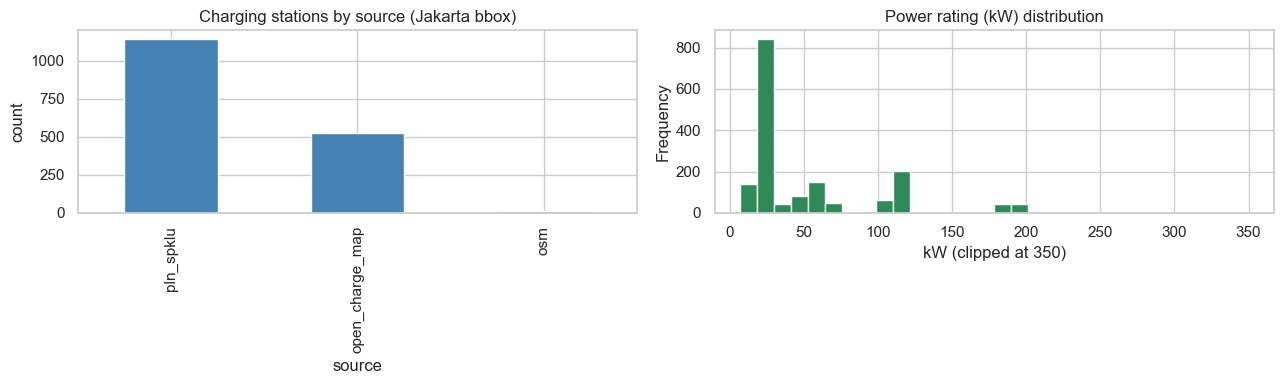

In [15]:
if not stations.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    stations['source'].value_counts().plot.bar(ax=axes[0], color='steelblue')
    axes[0].set_title('Charging stations by source (Jakarta bbox)')
    axes[0].set_ylabel('count')
    if stations['power_kw'].notna().any():
        stations['power_kw'].dropna().clip(upper=350).plot.hist(
            ax=axes[1], bins=30, color='seagreen')
        axes[1].set_title('Power rating (kW) distribution')
        axes[1].set_xlabel('kW (clipped at 350)')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'overview.png', dpi=120)
    plt.show()

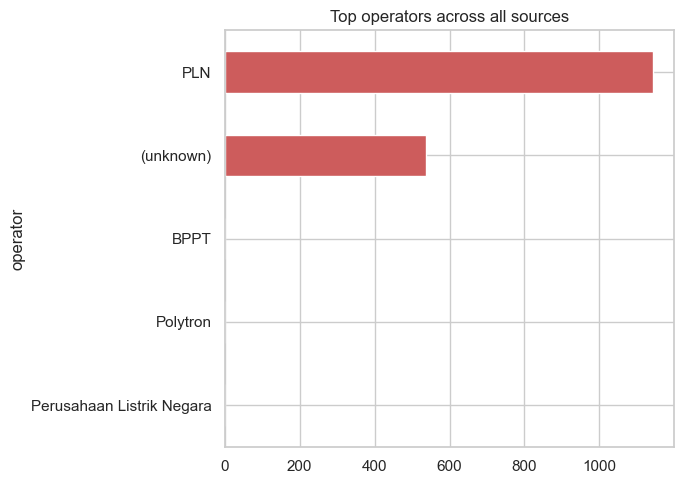

In [16]:
# Operator / brand mix
if not stations.empty and stations['operator'].notna().any():
    top_ops = stations['operator'].fillna('(unknown)').value_counts().head(15)
    top_ops.plot.barh(figsize=(7,5), color='indianred')
    plt.gca().invert_yaxis()
    plt.title('Top operators across all sources')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'operators.png', dpi=120)
    plt.show()

## 9. Spatial coverage — Folium map

In [17]:
import folium
from folium.plugins import MarkerCluster, HeatMap

if not stations.empty:
    palette = {'pln_spklu':'#d62728','open_charge_map':'#ff7f0e','osm':'#2ca02c'}
    label   = {'pln_spklu':'PLN SPKLU (official)','open_charge_map':'Open Charge Map','osm':'OpenStreetMap'}
    m = folium.Map(location=CENTER, zoom_start=11, tiles='CartoDB positron')

    for src, color in palette.items():
        sub = stations[stations['source'] == src]
        if sub.empty:
            continue
        fg = folium.FeatureGroup(name=f"{label[src]} ({len(sub)})", show=True)
        mc = MarkerCluster().add_to(fg)
        for _, r in sub.iterrows():
            popup = (f"<b>{r.get('name') or '(unnamed)'}</b><br>{r.get('operator') or ''}"
                     f"<br>{r.get('power_kw') or ''} kW<br><i>{label[src]}</i>")
            folium.CircleMarker([r['lat'], r['lon']], radius=4, color=color, fill=True,
                                fill_opacity=0.75, weight=1,
                                popup=folium.Popup(popup, max_width=260)).add_to(mc)
        fg.add_to(m)

    HeatMap(stations[['lat','lon']].values.tolist(), name='Density heatmap',
            radius=12, blur=18, show=False).add_to(m)

    counts = stations['source'].value_counts()
    legend = ("<div style=\"position:fixed;bottom:30px;left:30px;z-index:9999;background:white;"
              "padding:10px 14px;border:1px solid #999;border-radius:6px;font:13px sans-serif;"
              "box-shadow:0 1px 4px rgba(0,0,0,.3)\"><b>EV Charging — Greater Jakarta</b><br>"
              f"{len(stations):,} stations<br>"
              f"<span style='color:#d62728'>&#9679;</span> PLN SPKLU ({counts.get('pln_spklu',0)})<br>"
              f"<span style='color:#ff7f0e'>&#9679;</span> Open Charge Map ({counts.get('open_charge_map',0)})<br>"
              f"<span style='color:#2ca02c'>&#9679;</span> OpenStreetMap ({counts.get('osm',0)})</div>")
    m.get_root().html.add_child(folium.Element(legend))
    folium.LayerControl(collapsed=False).add_to(m)

    map_path = OUTPUT_DIR / 'jakarta_charging_map.html'
    m.save(map_path)
    print(f'Map written to {map_path}  ({len(stations):,} stations)')
    m


Map written to output\jakarta_charging_map.html  (1,682 stations)


## 10. OSRM — drive-time accessibility (sample)

For each of N sample origins in Jakarta, find drive time to the nearest charging station. The public OSRM demo server is rate-limited; for anything more than a quick sample, host your own.

In [18]:
osrm_base = os.getenv('OSRM_BASE_URL', 'https://router.project-osrm.org')
osrm_profile = os.getenv('OSRM_PROFILE', 'driving')

def osrm_route_seconds(orig, dest):
    """Return drive time in seconds between two (lat, lon) pairs."""
    url = f"{osrm_base}/route/v1/{osrm_profile}/{orig[1]},{orig[0]};{dest[1]},{dest[0]}"
    r = requests.get(url, params={'overview':'false'}, headers={'User-Agent': UA}, timeout=TIMEOUT)
    if not r.ok: return np.nan
    routes = r.json().get('routes') or []
    return routes[0]['duration'] if routes else np.nan

if not stations.empty:
    rng = np.random.default_rng(42)
    sample_origins = [
        (rng.uniform(BBOX['south'], BBOX['north']),
         rng.uniform(BBOX['west'],  BBOX['east']))
        for _ in range(8)
    ]
    rows = []
    for lat, lon in sample_origins:
        d_km = haversine_km(lat, lon, stations['lat'].values, stations['lon'].values)
        nearest_idx = int(np.argmin(d_km))
        dest = (stations.loc[nearest_idx, 'lat'], stations.loc[nearest_idx, 'lon'])
        secs = osrm_route_seconds((lat, lon), dest)
        rows.append({'origin_lat':lat,'origin_lon':lon,
                     'dest_lat':dest[0],'dest_lon':dest[1],
                     'crow_km':d_km[nearest_idx],
                     'drive_min': secs/60 if pd.notna(secs) else np.nan})
        time.sleep(1)  # be nice to demo server
    access = pd.DataFrame(rows)
    display(access)

,origin_lat,origin_lon,dest_lat,dest_lon,crow_km,drive_min
0,-6.108231,106.791383,-6.109464,106.791259,0.137815,0.365000
1,-6.048981,106.933552,-6.127900,106.926300,8.811915,14.093333
2,-6.584076,107.086592,-6.462196,107.059234,13.885374,27.283333
3,-6.117202,106.982335,-6.154245,106.982031,4.119114,19.175000
4,-6.560320,106.797712,-6.560036,106.788375,1.031945,8.001667
5,-6.390441,107.059721,-6.382608,107.040949,2.249826,6.871667
6,-6.199294,107.002519,-6.219651,106.999818,2.283157,6.933333
7,-6.339610,106.674981,-6.320107,106.679369,2.222198,4.713333


## 11. Cross-source comparison (sanity checks)

How much do the three station registries agree? A site found in Satu Data but missing from OSM is a candidate OSM edit; one in OCM but missing from Satu Data may be a private / unofficial site.

In [19]:
if not stations.empty:
    # Per-cluster source presence
    presence = (stations_dd.assign(v=1)
                .pivot_table(index='cluster', columns='source', values='v',
                             aggfunc='max', fill_value=0))
    print('Cluster counts by source-combination:')
    print(presence.astype(int).astype(str).agg('-'.join, axis=1).value_counts())
    presence.to_csv(PROCESSED_DIR / 'cluster_source_presence.csv')

Cluster counts by source-combination:
0-0-1    631
1-0-1    357
1-0-0    146
1-1-1      7
0-1-0      6
Name: count, dtype: int64


## 12. Next steps

- Geocode/normalize district (`kecamatan` / `kelurahan`) on every row, then join BPS denominators.
- Pull EV registration counts from Kaggle by region and compute `EVs per public connector`.
- Build proper drive-time isochrones (OSRM `/table`) over a Jakarta grid for accessibility heatmap.
- Time-stamp the OSM and OCM pulls and rerun monthly to track infrastructure growth.